<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/WaterQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pengatur Waktu**

In [1]:
import time
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")


⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 3.405 detik
Eksekusi berikutnya: 0.000 detik


**Import Library**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

**Load Dataset**

In [4]:
data = pd.read_excel("//content/WQD.xlsx")
print("Preview data:")
display(data.head())

Preview data:


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2


In [5]:
print("\nInfo kolom:")
print(data.info())


Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temp                  4300 non-null   float64
 1   Turbidity (cm)        4300 non-null   float64
 2   DO(mg/L)              4300 non-null   float64
 3   BOD (mg/L)            4300 non-null   float64
 4   CO2                   4300 non-null   float64
 5   pH`                   4300 non-null   float64
 6   Alkalinity (mg L-1 )  4300 non-null   float64
 7   Hardness (mg L-1 )    4300 non-null   float64
 8   Calcium (mg L-1 )     4300 non-null   float64
 9   Ammonia (mg L-1 )     4300 non-null   float64
 10  Nitrite (mg L-1 )     4300 non-null   float64
 11  Phosphorus (mg L-1 )  4300 non-null   float64
 12  H2S (mg L-1 )         4300 non-null   float64
 13  Plankton (No. L-1)    4300 non-null   float64
 14  Water Quality         4300 non-null   int64  
dtypes: float

In [6]:
print("\nChecking for missing values:")
print(data.isnull().sum())


Checking for missing values:
Temp                    0
Turbidity (cm)          0
DO(mg/L)                0
BOD (mg/L)              0
CO2                     0
pH`                     0
Alkalinity (mg L-1 )    0
Hardness (mg L-1 )      0
Calcium (mg L-1 )       0
Ammonia (mg L-1 )       0
Nitrite (mg L-1 )       0
Phosphorus (mg L-1 )    0
H2S (mg L-1 )           0
Plankton (No. L-1)      0
Water Quality           0
dtype: int64


In [7]:
print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)
print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())


Checking for duplicate rows before dropping:
0

Checking for duplicate rows after dropping:
0


In [8]:
display(data.head())
print("\nNew columns after selection:")
print(data.columns.tolist())

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2



New columns after selection:
['Temp', 'Turbidity (cm)', 'DO(mg/L)', 'BOD (mg/L)', 'CO2', 'pH`', 'Alkalinity (mg L-1 )', 'Hardness (mg L-1 )', 'Calcium (mg L-1 )', 'Ammonia (mg L-1 )', 'Nitrite (mg L-1 )', 'Phosphorus (mg L-1 )', 'H2S (mg L-1 )', 'Plankton (No. L-1)', 'Water Quality']


**Formatter kustom - Mengubah nilai dibelakang koma cuman ada dua angka**

In [9]:
import pandas as pd

def custom_float_formatter(x):
    if pd.isna(x):
        return None
    formatted_2dp = f"{x:.2f}"
    if formatted_2dp.endswith('.00'):
        return f"{x:.3f}"
    else:
        return formatted_2dp
float_cols = data.select_dtypes(include=['float64']).columns

formatter_dict = {col: custom_float_formatter for col in float_cols}
print("DataFrame dengan format desimal kustom (10 baris pertama):")
display(data.head(5).style.format(formatter_dict))

DataFrame dengan format desimal kustom (10 baris pertama):


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.45,10.13,0.21,7.47,10.18,4.75,218.36,300.13,337.18,0.29,4.36,0.01,0.07,6069.62,2
1,64.63,94.02,11.43,10.86,14.86,3.09,273.94,8.43,363.66,0.10,2.18,0.005,0.02,250.996,2
2,65.12,90.65,12.43,12.81,12.32,9.65,220.81,11.73,309.37,0.97,4.90,0.01,0.07,7218.93,2
3,1.64,0.07,10.96,8.51,12.96,4.82,266.57,6.63,8.18,0.88,3.57,3.17,0.03,1230.06,2
4,64.86,2.12,1.36,13.34,13.60,10.24,252.11,339.89,253.997,0.80,4.66,3.85,0.06,1035.05,2


In [10]:
print(f"Jumlah total data (baris): {len(data)}")

Jumlah total data (baris): 4300


**Correlation Matrix**

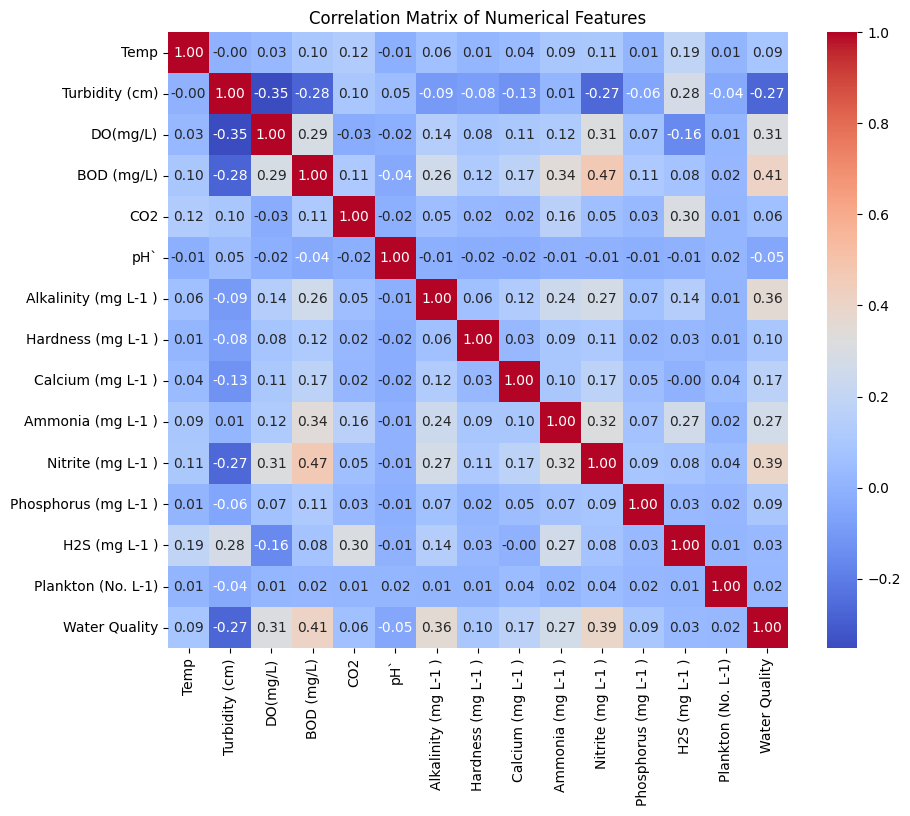

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
correlation_matrix = data.select_dtypes(include=['number']).corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Analisis Data Eksploratif (EDA)**

**Distribution of Water Quality**

In [12]:
print("Distribution of 'Water Quality' column:")
print(data['Water Quality'].value_counts())

Distribution of 'Water Quality' column:
Water Quality
2    1500
1    1400
0    1400
Name: count, dtype: int64


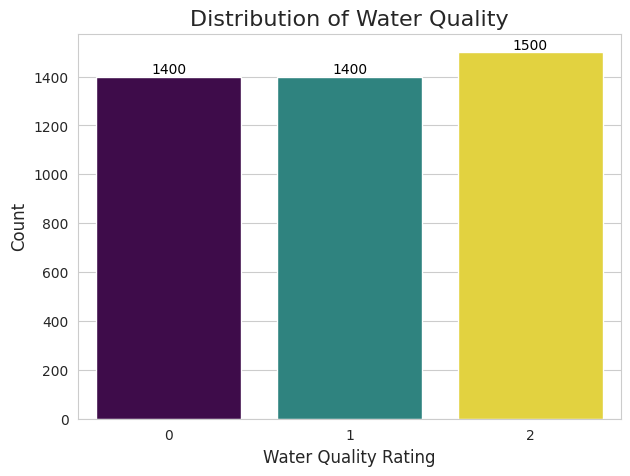

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style('whitegrid')

# Create a figure and an axes object
plt.figure(figsize=(7, 5))

# Create a count plot for the 'Water Quality' column
sns.countplot(x='Water Quality', data=data, palette='viridis', hue='Water Quality', legend=False)

# Add titles and labels
plt.title('Distribution of Water Quality', fontsize=16)
plt.xlabel('Water Quality Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add value counts on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.show()

**Distribution of colom by Water Quality**

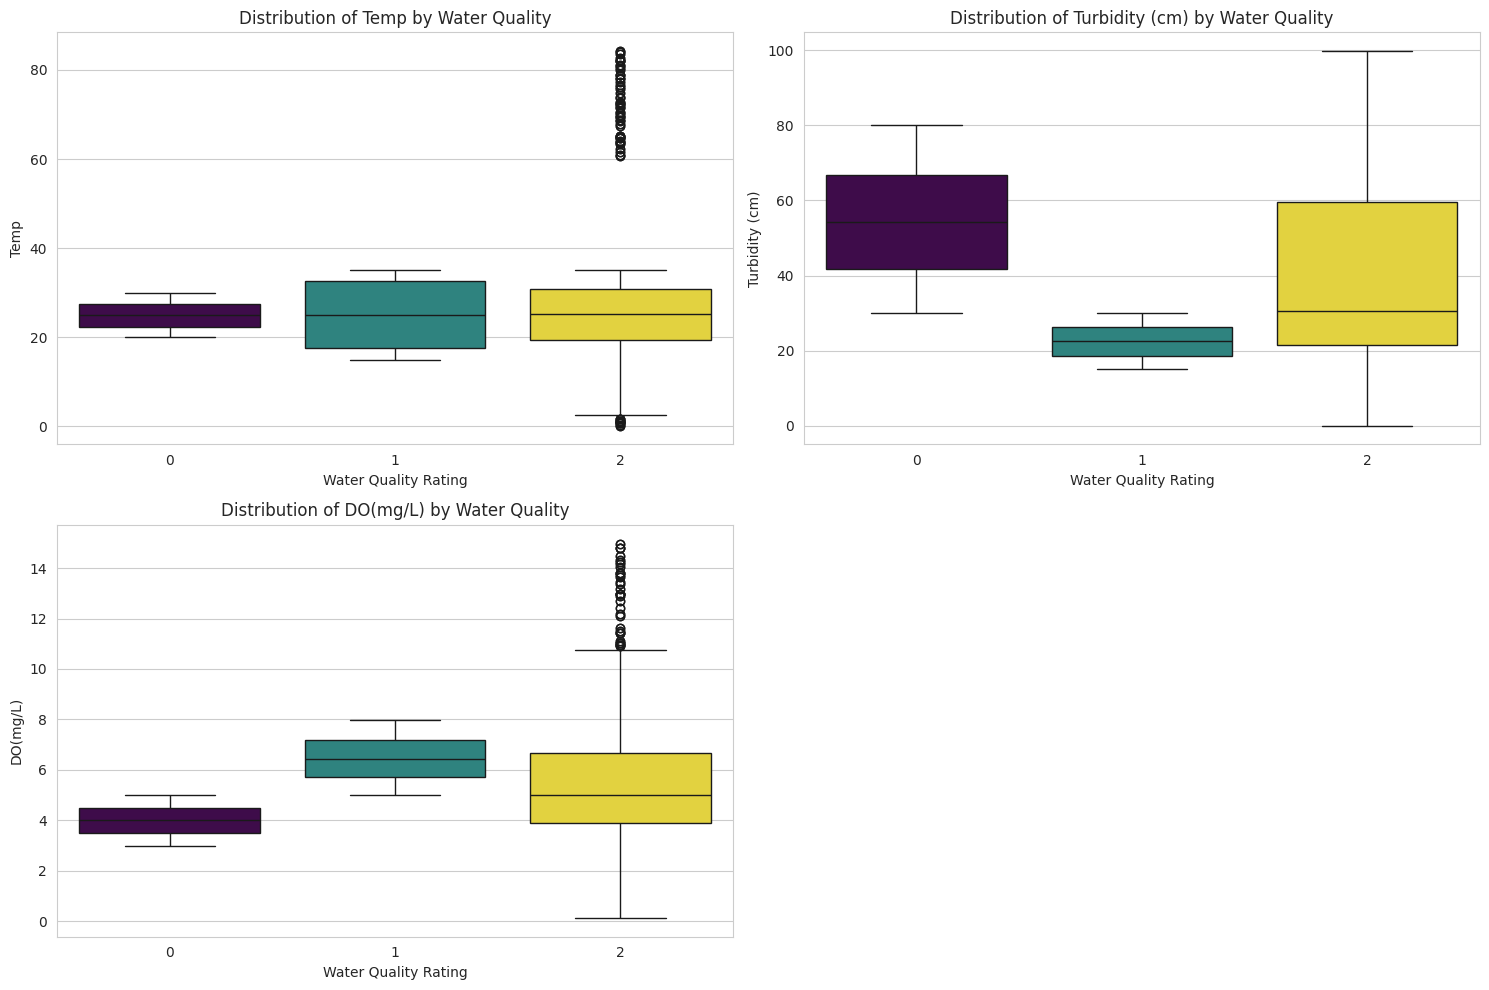

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: plotting some key numerical features against the 'Water Quality' status
relevant_numerical_cols = ['Temp', 'Turbidity (cm)', 'DO(mg/L)'] # Updated to actual columns in your data

# Set up the matplotlib figure and axes for subplots
n_cols = 2  # You can adjust this for more columns if needed
n_rows = (len(relevant_numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, col in enumerate(relevant_numerical_cols):
    sns.boxplot(x='Water Quality', y=col, data=data, ax=axes[i], palette='viridis', hue='Water Quality', legend=False) # Changed 'left' to 'Water Quality'
    axes[i].set_title(f'Distribution of {col} by Water Quality')
    axes[i].set_xlabel('Water Quality Rating')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Visualisasi Distribusi Fitur**

Number of rows before dropping NaNs: 4300
Number of rows after dropping NaNs: 4300


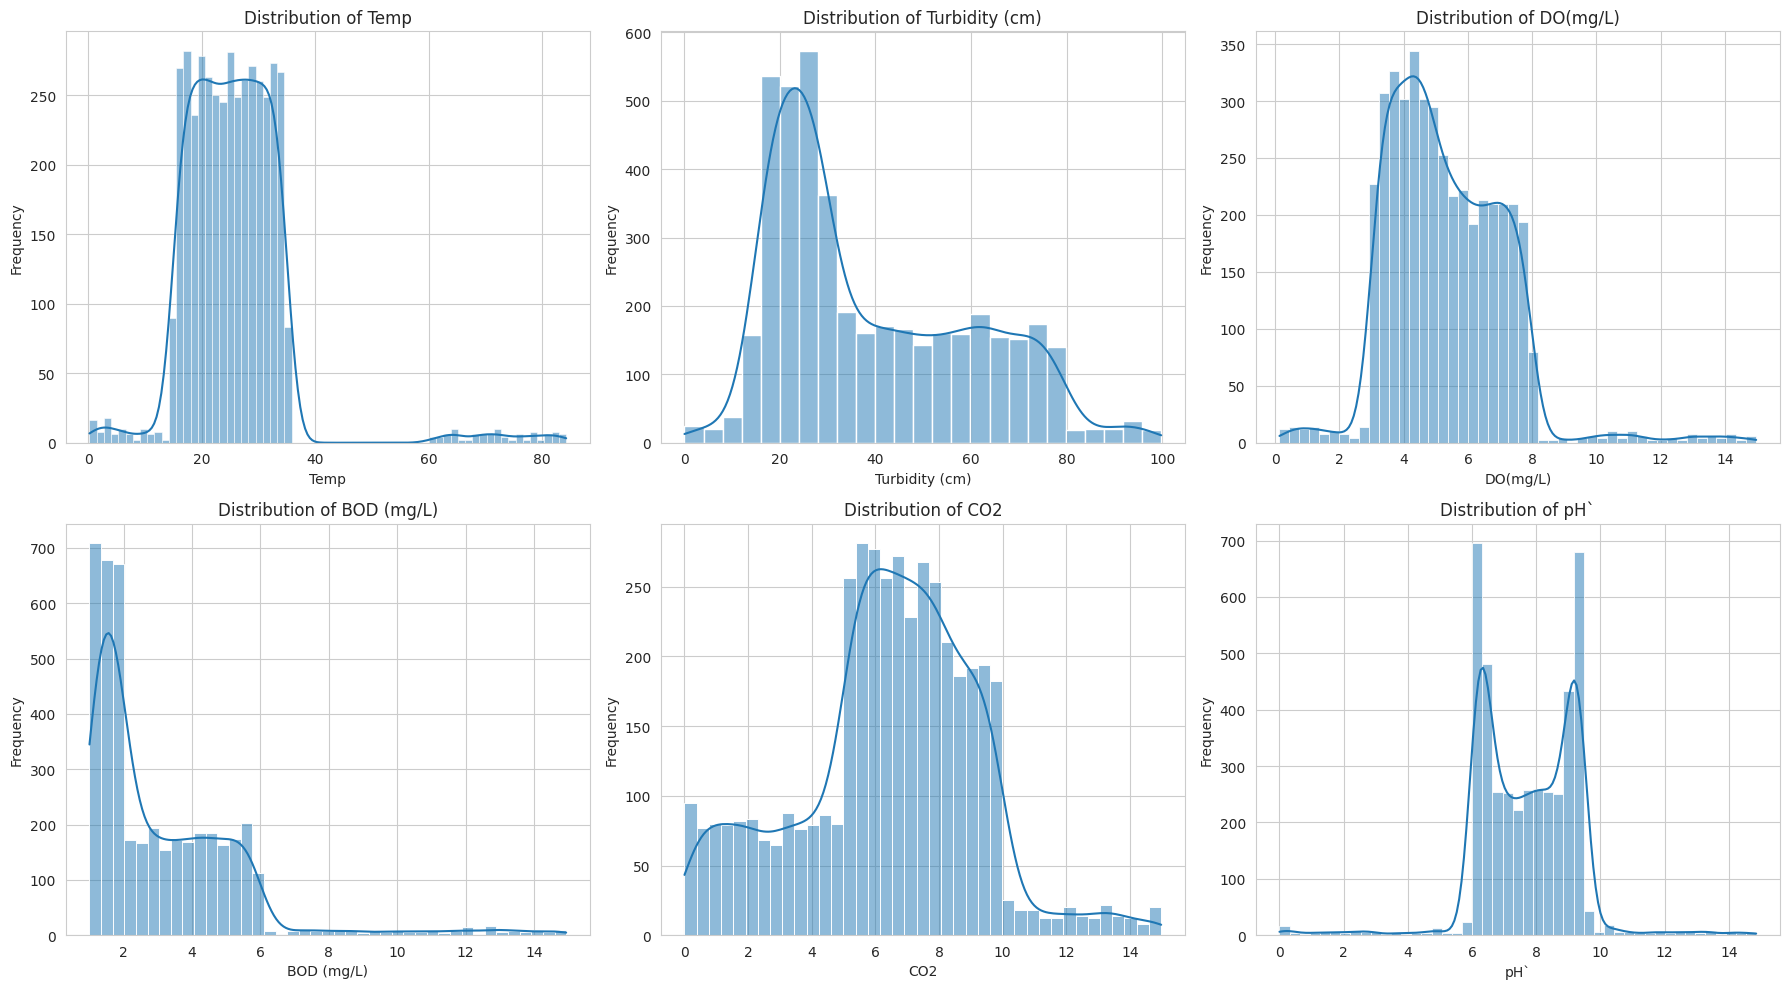


Skewness of numerical features after dropping NaNs:
Temp              2.534656
Turbidity (cm)    0.700381
DO(mg/L)          1.109894
BOD (mg/L)        2.205117
CO2              -0.157483
pH`              -0.380049
dtype: float64


In [15]:
print(f"Number of rows before dropping NaNs: {len(data)}")
data.dropna(inplace=True)
print(f"Number of rows after dropping NaNs: {len(data)}")

# Update numerical_cols_to_plot with actual columns from the water quality dataset
numerical_cols_to_plot = [
    'Temp',
    'Turbidity (cm)',
    'DO(mg/L)',
    'BOD (mg/L)',
    'CO2',
    'pH`' # Using the first 6 relevant numerical columns
]

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate n_rows and n_cols dynamically based on the number of columns to plot
n_cols = 3
n_rows = (len(numerical_cols_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols_to_plot):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print('\nSkewness of numerical features after dropping NaNs:')
print(data[numerical_cols_to_plot].skew())

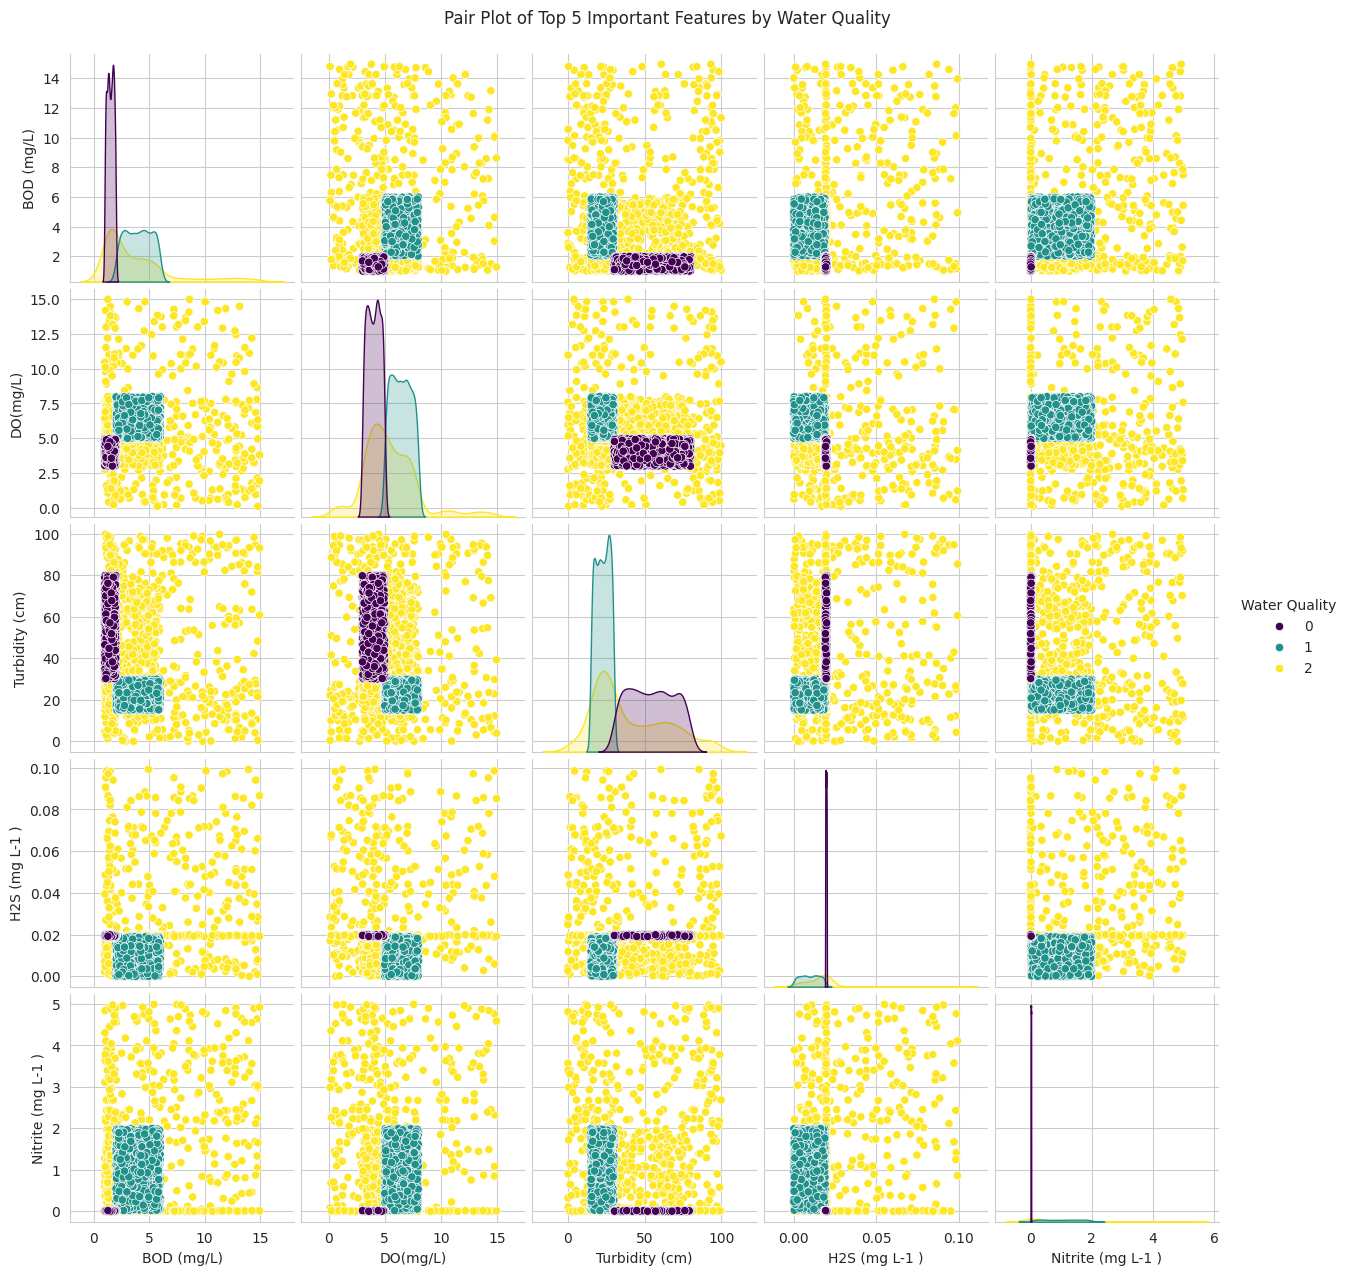

In [51]:
# Get the top 5 most important features
top_features = sorted_feature_importances.head(5).index.tolist()

# Generate scatter plots for pairs of top features, colored by Water Quality
sns.pairplot(data, vars=top_features, hue='Water Quality', palette='viridis')
plt.suptitle('Pair Plot of Top 5 Important Features by Water Quality', y=1.02)
plt.show()

**Split Data**

In [16]:
# Define features (X) and target (y) based on the current 'data' DataFrame
# 'Water Quality' is the target variable
X = data.drop(['Water Quality'], axis=1) # Drop the target variable to get features
y = data['Water Quality'] # Select 'Water Quality' as the target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (3440, 14)
X_test shape: (860, 14)
y_train shape: (3440,)
y_test shape: (860,)


### Feature Scaling

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features scaled successfully!
X_train_scaled shape: (3440, 14)
X_test_scaled shape: (860, 14)


In [20]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_train_normalized = minmax_scaler.fit_transform(X_train_scaled)
X_test_normalized = minmax_scaler.transform(X_test_scaled)

print("Features normalized using MinMaxScaler successfully!")
print(f"X_train_normalized shape: {X_train_normalized.shape}")
print(f"X_test_normalized shape: {X_test_normalized.shape}")

Features normalized using MinMaxScaler successfully!
X_train_normalized shape: (3440, 14)
X_test_normalized shape: (860, 14)


### Cross-Validation

Cross-validation adalah teknik yang digunakan untuk menilai seberapa baik model machine learning Anda akan digeneralisasi ke dataset independen. Teknik ini terutama digunakan dalam pengaturan di mana tujuannya adalah untuk memperkirakan seberapa akurat model akan bekerja dalam praktiknya. Kita akan menggunakan K-Fold Cross-Validation dengan 5 folds.

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Initialize a KNeighborsClassifier model
knn = KNeighborsClassifier()

# Perform 5-fold cross-validation on the normalized training data
# We use the normalized training data to evaluate the model's performance consistently
cv_scores = cross_val_score(knn, X_train_normalized, y_train, cv=5, scoring='accuracy')

print("Cross-validation scores (accuracy) for each fold:")
print(cv_scores)
print(f"\nMean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of CV accuracy: {cv_scores.std():.4f}")

Cross-validation scores (accuracy) for each fold:
[0.8502907  0.87645349 0.86482558 0.8502907  0.87209302]

Mean CV accuracy: 0.8628
Standard deviation of CV accuracy: 0.0109


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.naive_bayes import GaussianNB

pipeline = Pipeline([
    ('pt', PowerTransformer()),
    ('fs', SelectKBest(mutual_info_classif, k=20)),
    ('nb', GaussianNB())
])

pipeline.fit(X_train_normalized, y_train)
y_pred = pipeline.predict(X_test_normalized)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=20 is greater than n_features=14. All the features will be returned.
  warnings.warn(


In [27]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Gaussian Naive Bayes model
nb_model = GaussianNB()

# Train the model using the normalized training data
nb_model.fit(X_train_normalized, y_train)

print("Gaussian Naive Bayes model trained successfully!")

Gaussian Naive Bayes model trained successfully!


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

# 1. Create a Pipeline
pipeline = Pipeline([
    ('fs', SelectKBest(mutual_info_classif)),
    ('nb', GaussianNB())
])

# 2. Define a parameter grid
param_grid = {
    'fs__k': [5, 7, 10, 14], # k values for feature selection, up to 14 features
    'nb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5] # var_smoothing values for GaussianNB
}

# 3. Initialize GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# 4. Fit the GridSearchCV object
print("\nStarting GridSearchCV to find optimal parameters...")
grid_search.fit(X_train_normalized, y_train)

# 5. Print the best_params_
print("\nBest parameters found by GridSearchCV:")
print(grid_search.best_params_)



Starting GridSearchCV to find optimal parameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters found by GridSearchCV:
{'fs__k': 14, 'nb__var_smoothing': 1e-09}


In [53]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Accuracy of the optimized Gaussian Naive Bayes model: {accuracy_optimized:.4f}")

# Generate and print classification report
print("\nClassification Report for Optimized Gaussian Naive Bayes Model:")
print(classification_report(y_test, y_pred_optimized))

Accuracy of the optimized Gaussian Naive Bayes model: 0.8907

Classification Report for Optimized Gaussian Naive Bayes Model:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       261
           1       0.81      1.00      0.90       274
           2       1.00      0.71      0.83       325

    accuracy                           0.89       860
   macro avg       0.90      0.90      0.89       860
weighted avg       0.91      0.89      0.89       860



In [56]:
import pandas as pd

# 1. Create a new Pandas DataFrame for comparison
gnb_comparison_df = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': y_pred_optimized
})

# 2. Print a header indicating that the following output is a comparison
print("\nPerbandingan Nilai Aktual dan Prediksi (Optimized Gaussian Naive Bayes Model):")

# 6. If gnb_incorrect_predictions is not empty, display its first few rows. Otherwise, print a message.
if not gnb_incorrect_predictions.empty:
    display(gnb_incorrect_predictions.head(10))
else:
    print("Tidak ada prediksi yang salah ditemukan.")


Perbandingan Nilai Aktual dan Prediksi (Optimized Gaussian Naive Bayes Model):


,Actual,Predicted
4,2,1
7,2,1
57,2,1
60,2,1
68,2,0
77,2,1
82,2,0
88,2,0
91,2,0
102,2,1


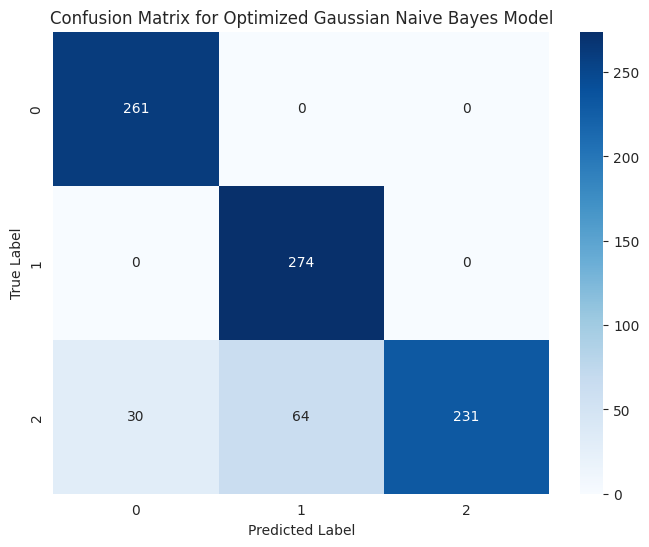

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the optimized Gaussian Naive Bayes model
cm_gnb = confusion_matrix(y_test, y_pred_optimized)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2]) # Assuming class labels are 0, 1, 2
plt.title('Confusion Matrix for Optimized Gaussian Naive Bayes Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**ROC Curve and AUC Score**

### ROC Curve dan AUC Score (Multi-class One-vs-Rest)

Untuk klasifikasi multi-kelas, kita akan menghitung dan memvisualisasikan ROC Curve menggunakan strategi One-vs-Rest (OvR). Ini melibatkan pelatihan model biner untuk setiap kelas, di mana satu kelas diperlakukan sebagai kelas positif dan semua kelas lainnya sebagai kelas negatif. Kita juga akan menghitung AUC Score untuk setiap kelas.

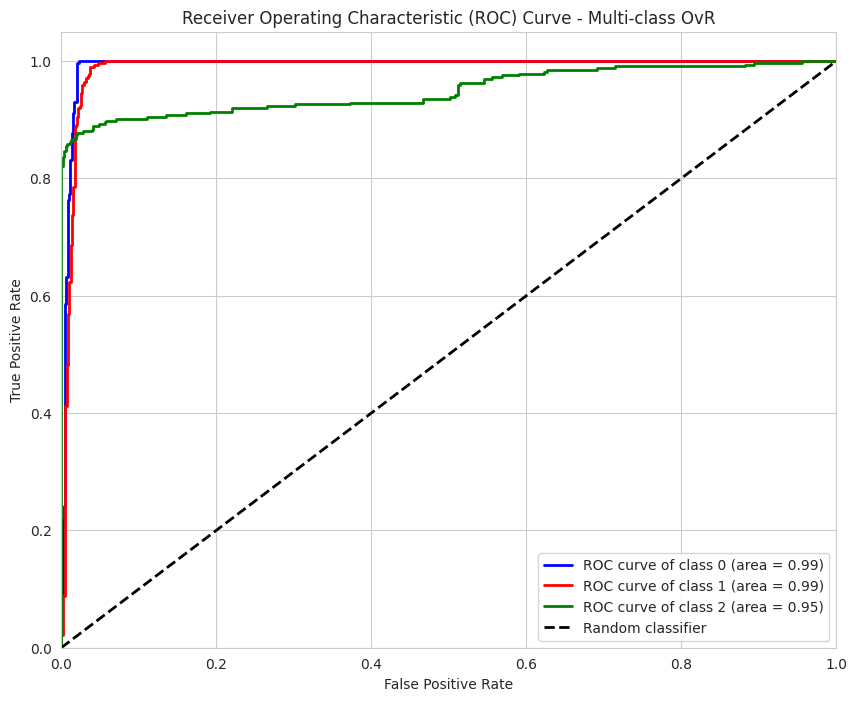


AUC Scores for each class (One-vs-Rest):
Class 0: 0.99
Class 1: 0.99
Class 2: 0.95


In [57]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize the target labels for multi-class ROC
# y_test and y_pred_optimized are already numerical labels 0, 1, 2
# We need to transform y_test and y_scores (probabilities) into one-hot encoded format

# First, check if the model has a predict_proba method
# If it does, use it. If not, we might need to re-train a model that does,
# or for simplicity, we'll assume a model with predict_proba for now

# In our case, the best_model from GridSearchCV was a Pipeline ending with GaussianNB.
# GaussianNB has predict_proba.

# Get the best estimator from GridSearchCV (which is a Pipeline)
# Make sure best_model is accessible, if not, re-run the GridSearchCV cell first.
# Assuming best_model is available from previous GridSearchCV

# If best_model is not available (e.g., if you skipped running the GridSearchCV cell),
# you might need to initialize it again: best_model = grid_search.best_estimator_

# Get decision function scores or probabilities for ROC curve
# For GaussianNB, predict_proba returns probabilities
y_score = best_model.predict_proba(X_test_normalized)

# Binarize the true labels
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)

# Plotting ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green'] # One color per class
auc_scores = []

for i in range(len(label_binarizer.classes_)):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of class {label_binarizer.classes_[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-class OvR')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("\nAUC Scores for each class (One-vs-Rest):")
for i, score in enumerate(auc_scores):
    print(f"Class {label_binarizer.classes_[i]}: {score:.2f}")

**Feature Importances**

In [48]:
# Get feature importances from the trained model
feature_importances = rf_model.feature_importances_

# Create a pandas Series for better visualization
feature_importance_series = pd.Series(feature_importances, index=X_train.columns)

# Sort the features by importance in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

print("Feature Importances (sorted):")
print(sorted_feature_importances)

Feature Importances (sorted):
BOD (mg/L)              0.148209
DO(mg/L)                0.146265
Turbidity (cm)          0.131393
H2S (mg L-1 )           0.114507
Nitrite (mg L-1 )       0.112670
Ammonia (mg L-1 )       0.099523
CO2                     0.076191
Temp                    0.062087
Alkalinity (mg L-1 )    0.053986
Hardness (mg L-1 )      0.014573
Plankton (No. L-1)      0.012675
Phosphorus (mg L-1 )    0.010309
Calcium (mg L-1 )       0.009021
pH`                     0.008592
dtype: float64


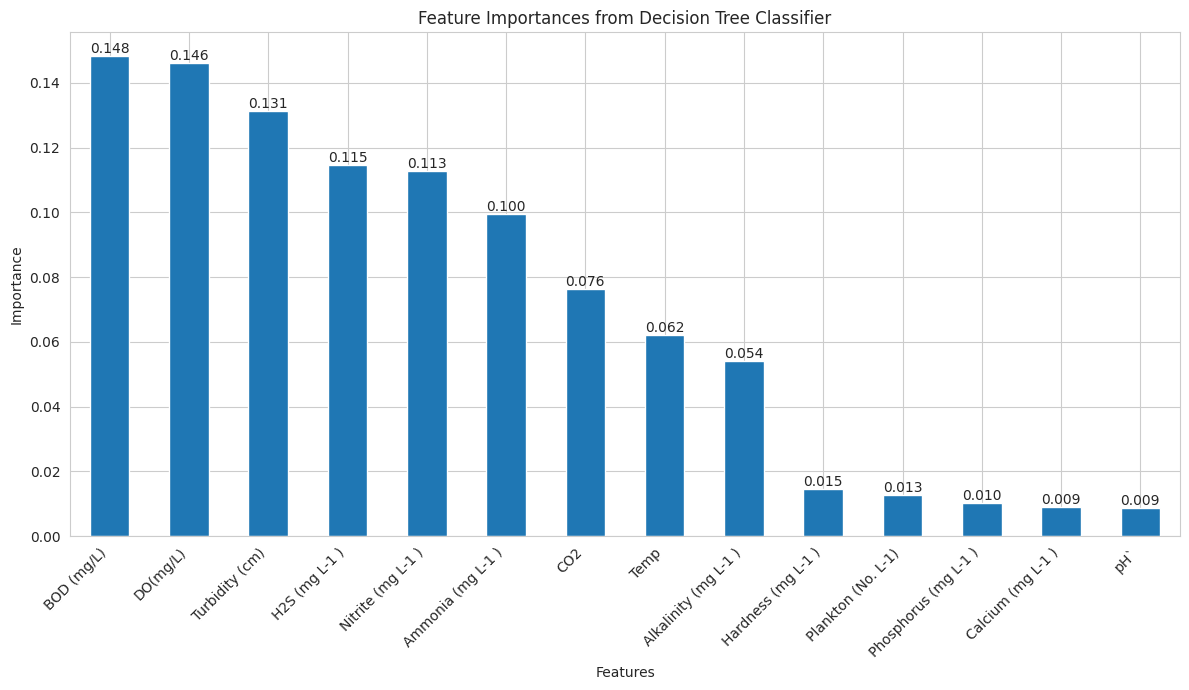

In [49]:
# Optional: Visualize feature importances
plt.figure(figsize=(12, 7)) # Increased figure size slightly for better readability
ax = sorted_feature_importances.plot(kind='bar')
plt.title('Feature Importances from Decision Tree Classifier')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f') # Format the labels to 3 decimal places

plt.show()